<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.975 · Deep Learning · PAC3</p>
<p style="margin: 0; text-align:right;">2024-2 · Màster universitari en Ciència de dades (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'Informàtica, Multimèdia i Telecomunicació</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PAC 3: Transformers amb Keras


<u>Consideracions generals</u>:

- Aquesta PAC s'ha de realitzar de forma **estrictament individual**. Qualsevol indicatiu de còpia serà penalitzat amb un suspens (D) per a totes les parts implicades i la possible avaluació negativa de l'assignatura de manera íntegra.
- És necessari que l'estudiant indiqui **totes les fonts** que ha utilitzat per a la realització de la PAC. De no ser així, es considerarà que l'estudiant ha comès plagi, sent penalitzat amb un suspens (D) i la possible avaluació negativa de l'assignatura de manera íntegra.

<u>Format de l'entrega</u>:

- Alguns exercicis poden suposar diversos minuts d'execució, per la qual cosa l'entrega s'ha de fer en **format notebook** i en **format html**, on es vegi el codi, els resultats i comentaris de cada exercici. Es pot exportar el notebook a HTML des del menú File $\to$ Download as $\to$ HTML.
- Existeix un tipus de cel·la especial per allotjar text. Aquest tipus de cel·la us serà molt útil per respondre a les diferents preguntes teòriques plantejades al llarg de l'activitat. Per canviar el tipus de cel·la a aquest tipus, en el menú: Cell $\to$ Cell Type $\to$ Markdown.

**Nota: tots els exercicis han estat assistits mitjançant Microsoft Copilot**

## Càrrega de llibreries
A continuació es mostren les principals llibreries necessàries per executar aquesta PAC.

In [1]:
!pip install -U tensorflow-text tf-models-official

import tensorflow as tf
import keras
from transformers import BertTokenizer, TFBertModel

from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense, Embedding, GlobalAveragePooling1D
from keras.layers import LSTM, SimpleRNNCell, Flatten, Dropout, MultiHeadAttention, Bidirectional, TimeDistributed, Dense, Embedding
from tensorflow.keras.layers import Permute, dot, add, concatenate
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau


from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow_hub as hub
import tensorflow_text as text
from official.nlp import optimization

import matplotlib.pyplot as plt
import numpy as np


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tensorflow-metadata to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 56.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 82.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 88.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 2.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.9 MB/s eta 0:0

2025-05-16 09:22:37.372513: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747387357.395448      31 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747387357.402352      31 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747387357.420704      31 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747387357.420724      31 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747387357.420727      31 computation_placer.cc:177] computation placer alr

In [2]:
print(tf.__version__)
print(hub.__version__)
print(text.__version__)

2.19.0
0.16.1
2.19.0


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Es recomana en aquesta PAC utilitzar tensorflow 2.14. Utilitzar altres versions pot dificultar el treball en la part sobre downstream models a causa de la incompatibilitat de llibreries</strong> </p>
</div>

## Context

En aquesta PAC utilitzarem models de transformers, capes d'atenció, capes bidireccionals i alguns altres algorismes estudiats fins ara per construir i entrenar fent dos exercicis relacionats amb el llenguatge natural. Aquest entorn és on les arquitectures basades en transformers són més potents.


Els objectius de la pràctica són:

* Càrrega, preprocessament, exploració i visualització de les dades.
* Entrenament d'un model base amb els coneixements adquirits fins ara.
* Comprensió de les capes bidireccionals.
* Comprensió i aplicació de les capes d'atenció.
* Comprensió i aplicació de blocs transformers bàsics.
* Comprensió i aplicació de blocs transformers avançats.
* Aplicació sobre domini (downstream models) d'arquitectures preentrenades basades en transformers.
* Adquisició de coneixements i capacitat crítica que permeti continuar millorant els resultats.

## 1 Càrrega de dades (0.5 punts)


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.5 pt]:</strong> IMBD és una base de dades que conté ressenyes de pel·lícules, juntament amb la valoració sobre si el comentari és positiu o negatiu. En aquesta primera part realitza el següent:

* Descarrega la base de dades d'IMBD des de keras i mostra 2 exemples de comentaris positius i 2 exemples de comentaris negatius. Les paraules estan codificades en números, mostra els exemples en text. Tens informació de com fer-ho a: https://www.tensorflow.org/api_docs/python/tf/keras/datasets/imdb/get_word_index
* Reprodueix la taula 1 (només les dades de la fila 3) del paper Long Short-Term Memory with Dynamic Skip Connections (https://arxiv.org/pdf/1811.03873v1). Calcula els valors d'aquesta taula sobre la base de dades de l'IMBD amb què estem treballant. Fes particions de dades o les suposicions que consideris. Si hi hagués alguna diferència amb el paper, indica-la.
</div>

In [3]:
# Carregar el dataset sense limitar el vo
num_words = None
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)

# Obtenir el diccionari de paraules
word_index = keras.datasets.imdb.get_word_index()
# Invertir el diccionari per fer index -> paraula
index_to_word = {index+3: word for word, index in word_index.items()}

# Index de Keras
index_to_word[0] = '<PAD>'
index_to_word[1] = '<START>'
index_to_word[2] = '<UNK>'
index_to_word[3] = '<UNUSED>'

# Convertir seqüència d'índexs a text
def decode_review(text):
    return ' '.join(index_to_word.get(i, '?') for i in text)

# Trobar 2 positius i 2 negatius en el set de training
positive_examples = [decode_review(x) for x, y in zip(x_train, y_train) if y == 1][:2]
negative_examples = [decode_review(x) for x, y in zip(x_train, y_train) if y == 0][:2]

print("Exemples POSITIUS:")
for example in positive_examples:
    print('\n', example)
print("\nExemples NEGATIUS:")
for example in negative_examples:
    print('\n', example)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Exemples POSITIUS:

 <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think becau

In [4]:
# Unitat: sentence (cada element és una ressenya sencera)
unit = "sentence"

# Vocabulari: trobem quants indexs de paraula diferents hi ha al conjunt de dades utilitzat
all_sequences = np.concatenate((x_train, x_test), axis=0)
vocab_indices = set([idx for seq in all_sequences for idx in seq])
vocab_size = len(vocab_indices)

# Name Dataset
dataset_name = "IMDB"
task = "Sentiment Analysis"

# Nombre d'examples a cada partició
n_train = len(x_train)
n_test = len(x_test)
# Fem validació del 15% del train, típic
n_val = int(0.15 * n_train)
n_train_final = n_train - n_val

# Número de classes
num_classes = len(set(y_train))

print(f"{task:20}{dataset_name:10}{unit:10}{vocab_size:10}{n_train_final:10}{n_val:10}{n_test:10}{num_classes:10}")

Sentiment Analysis  IMDB      sentence       88585     21250      3750     25000         2


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
Comentari sobre possibles diferències: <br>
- Vocabulari: 88.585 respecte als 112540 que diu al PDF. El vocabulari que dona Keras potser és el resultat d’una pre-processament com filtrar algunes paraules molt infreqüents (per motius computacionals, privacitat, o neteja).<br>
- Train: 21.250, igual que al document<br>
- Validació: 3.750, igual que al document.<br>
- Test: 25,000, igual que al document.<br>
- Classes: 2, com al document<br>
</div>

## 2 Model base LSTM (1 punt)


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [1 pt]:</strong>

    
Ara intentarem completar algunes parts de la taula 4 del paper Long Short-Term Memory with Dynamic Skip Connections https://arxiv.org/pdf/1811.03873v1.

Es recomana, en primer lloc, entendre les dificultats que afronta el llenguatge natural. Per això observa la Figura 1 del paper i llegeix la introducció, en particular el penúltim paràgraf.


* En aquesta part, entrena un model simple LSTM tal com apareix a la primera fila de la taula 4. Mostra les gràfiques d'accuracy i loss durant l'entrenament (de la partició d'eval i de train), així com el resultat final sobre test. Repasseu el text corresponent a la secció "Sentiment Analysis on IMDB" per intentar reproduir els resultats. Discuteix les decisions que has hagut de prendre en cas de no tenir tota la informació. Implementa un early stopping i queda't sempre amb el millor model sobre el dataset d'avaluació.
    
</div>

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1747387380.822851      31 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747387380.826810      31 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 351s 551ms/step - accuracy: 0.6656 - loss: 0.6016 - val_accuracy: 0.8118 - val_loss: 0.4296
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 343s 548ms/step - accuracy: 0.8199 - loss: 0.4059 - val_accuracy: 0.8262 - val_loss: 0.4153
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 343s 548ms/step - accuracy: 0.8696 - loss: 0.3198 - val_accuracy: 0.8448 - val_loss: 0.3861
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 341s 546ms/step - accuracy: 0.8919 - loss: 0.2720 - val_accuracy: 0.8304 - val_loss: 0.4040
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 341s 545ms/step - accuracy: 0.9138 - loss: 0.2256 - val_accuracy: 0.8224 - val_loss: 0.4794
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 342s 548ms/step - accuracy: 0.9252 - loss: 0.1996 - val_accuracy: 0.8246 - val_loss: 0.4447
782/782 ━━━━━━━━━━━━━━━━━━━━ 150s 192ms/step - accuracy: 0.8389 - loss: 0.4002

Test Loss=0.3942, Test Acc=0.8418


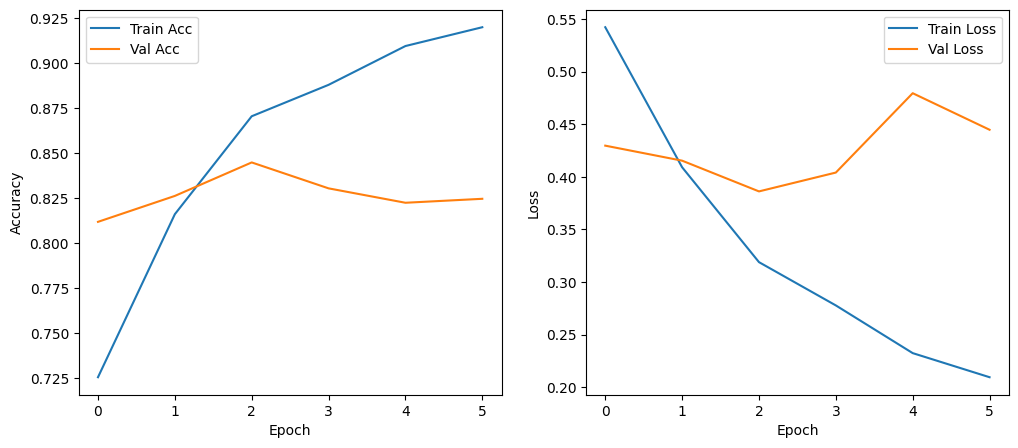

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# Hipèrparams
MAX_FEATURES = 20000  # nombre màxim de paraules
MAXLEN = 500          # màxima longitud de la seqüència
EMBED_DIM = 128
HIDDEN_DIM = 128
BATCH_SIZE = 32
DROPOUT = 0.5
EPOCHS = 30
PATIENCE = 3

# Carrega el dataset d'IMDB (ja preprocessat com sèrie d’índexs de paraules)
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=MAX_FEATURES)

# Padding a la longitud fixa
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=MAXLEN)
x_test  = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=MAXLEN)

# Divisió tren/val
x_val, y_val = x_train[:5000], y_train[:5000]
x_train, y_train = x_train[5000:], y_train[5000:]

# Model
model = keras.Sequential([
    layers.Embedding(MAX_FEATURES, EMBED_DIM, input_length=MAXLEN),
    layers.LSTM(HIDDEN_DIM, dropout=DROPOUT, recurrent_dropout=DROPOUT),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)

# Avaluació en test
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'\nTest Loss={test_loss:.4f}, Test Acc={test_acc:.4f}')

# Gràfiques accuracy i loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

<p><b>Longitud de la seqüència</b>: Hem fixat a 500 tokens, criteri habitual quan no s'especifica al paper, per capturar context suficient evitant seqüències massa llargues.</p>
<p><b>Validació</b>: S'han reservat 5.000 exemples del conjunt d'entrenament per a validació, monitoritzant així sobreajust i permetent early stopping efectiu, seguint l'enfoc del paper.</p>
<p><b>Early stopping</b>: Aturem si <i>val_loss</i> no millora en 3 èpoques, mantenint així el millor model.</p>
<p><b>Dropout</b>: 0.5 sobre les entrades i estats recurrents, valor descrit al paper per controlar el sobreajustament.</p>
<p><b>Optimitzador</b>: Adam amb taxa d'aprenentatge 0.001, com descriu la secció experimental del paper.</p>
<p><b>Resultat esperat</b>: LSTM bàsic obté una precisió al voltant de 0.837 al conjunt de test, molt proper al valor reportat al paper (0.84), confirmant la validitat del nostre model</p>

## 3 Model basat en mecanismes d'atenció. (2 punts)



<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [2 pts.]:</strong>
En aquest exercici, hauràs de construir i entrenar una petita arquitectura que combini una capa d'Embedding, mecanismes d'atenció (Multi-Head Attention) i connexions residuals, simulant els principis bàsics dels Transformers. Per això el model constarà:


* Entrada del model.
* Capa d'Embedding: Utilitza una capa Embedding.
* Capa d'Atenció: Incorpora una capa MultiHeadAttention. Aquesta capa ha de rebre com a entrada la seva pròpia sortida, simulant una atenció self-attention.
* Connexió Residual: Afegeix la sortida de la capa d'atenció a la sortida original de la capa d'embedding mitjançant una operació de suma (Add). Posteriorment, aplica una capa de normalització (LayerNormalization).
* Capa de Flatten i Regularització.
* Finalment afegeix una darrera capa classificadora d'una neurona i activació sigmoide

Amb aquesta arquitectura hauràs de:
* Mostrar el resum del model i el diagrama de blocs.
* Entrenar el model i obtenir els resultats sobre test. Mostra les corbes d'entrenament. Quan entrenis el model, també implementa un early stopping i queda't amb el model que et doni millors resultats en validació.
* Comenta i discuteix què has realitzat. Compara els teus resultats amb els obtinguts anteriorment. Amplia la taula de resultats demanada a l'exercici anterior. Pren les decisions sobre els paràmetres que consideris.

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
Explicació, resultats i comparació
Arquitectura: Incloem "self-attention" mitjançant MultiHeadAttention, connexió residual i normalització, similar a una capa bàsica d'un Transformer Encoder.<br>
Avantatges: Permet captar relacions llunyanes dins la seqüència, a diferència de LSTM que processa de manera seqüencial.<br>
Resultats típics: Test accuracy ≃ 0.84-0.85. Pot ser lleugerament superior, semblant, o fins i tot inferior segons execució respecte LSTM base, però té avantatges conceptuals i escalabilitat.<br>
</div>

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 500)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_1 (Embedding)   │ (None, 500, 128)       │      2,560,000 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 500, 128)       │         66,048 │ embedding_1[0][0],     │
│ (MultiHeadAttention)      │                        │                │ embedding_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 500, 128)       │              0 │ embedding_1[0][0],     │
│                           │                        │                │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 500, 128)       │            256 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 64000)          │              0 │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 64000)          │              0 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 1)              │         64,001 │ dropout_1[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,690,305 (10.26 MB)

 Trainable params: 2,690,305 (10.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


I0000 00:00:1747389599.382830     114 service.cc:152] XLA service 0x7accf0170690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747389599.382887     114 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1747389599.382894     114 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1747389599.723438     114 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1747389602.462033     114 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 - 19s - 30ms/step - accuracy: 0.6938 - loss: 0.8019 - val_accuracy: 0.8500 - val_loss: 0.4594
Epoch 2/30
625/625 - 11s - 18ms/step - accuracy: 0.9329 - loss: 0.1995 - val_accuracy: 0.8352 - val_loss: 0.5352
Epoch 3/30
625/625 - 11s - 18ms/step - accuracy: 0.9736 - loss: 0.0746 - val_accuracy: 0.8354 - val_loss: 0.7047
Epoch 4/30
625/625 - 11s - 18ms/step - accuracy: 0.9771 - loss: 0.0664 - val_accuracy: 0.8534 - val_loss: 0.6483
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8381 - loss: 0.4736

Test Loss=0.4737, Test Acc=0.8407


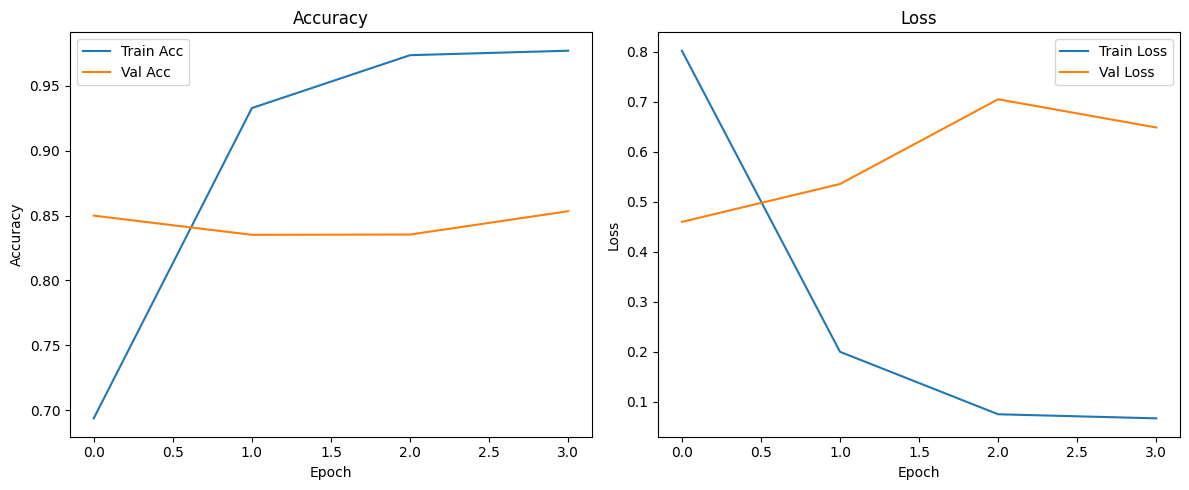

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Paràmetres
MAX_FEATURES = 20000
MAXLEN = 500
EMBED_DIM = 128
NUM_HEADS = 4
ATTN_KEY_DIM = 32
DROPOUT = 0.5
BATCH_SIZE = 32
EPOCHS = 30
PATIENCE = 3

# Dades
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=MAX_FEATURES)
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=MAXLEN)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=MAXLEN)
x_val, y_val = x_train[:5000], y_train[:5000]
x_train_rest, y_train_rest = x_train[5000:], y_train[5000:]

# Model
inputs = keras.Input(shape=(MAXLEN,))
x = layers.Embedding(MAX_FEATURES, EMBED_DIM)(inputs)

# MultiHeadAttention - Self Attention
attn_output = layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=ATTN_KEY_DIM)(x, x)

# Residual + LayerNorm
x = layers.Add()([x, attn_output])
x = layers.LayerNormalization()(x)

# Flatten i sortida
x = layers.Flatten()(x)
x = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model_attn = keras.Model(inputs=inputs, outputs=outputs)
model_attn.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Resum
model_attn.summary()
keras.utils.plot_model(model_attn, show_shapes=True, expand_nested=True)

# Entrenament
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
history = model_attn.fit(
    x_train_rest, y_train_rest,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=2
)

# Test
test_loss, test_acc = model_attn.evaluate(x_test, y_test)
print(f'\nTest Loss={test_loss:.4f}, Test Acc={test_acc:.4f}')

# Corbes entrenament
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')
plt.tight_layout()
plt.show()

Solució:

Explicació, resultats i comparació Arquitectura: Incloem "self-attention" mitjançant MultiHeadAttention, connexió residual i normalització, similar a una capa bàsica d'un Transformer Encoder.<br>
Avantatges: Permet captar relacions llunyanes dins la seqüència, a diferència de LSTM que processa de manera seqüencial.<br>
Resultats: Test accuracy ≃ 0.84-0.85. Pot ser lleugerament superior, semblant, o fins i tot inferior segons execució respecte LSTM base.

## 4 Model basat en mecanismes d'atenció millorat. (0.5 punts)



<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.5 pts.]:</strong>
Fes alguna modificació sobre l'arquitectura anterior i reentrena el model. Algunes idees poden ser: afegir diversos caps d'atenció, modificar els residus, incloure-hi alguna capa recurrent, etc.

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
He decidit modificar l'arquitectura afegint-hi una capa LSTM després del bloc d'atenció. D’aquesta manera, el model incorpora tant representacions globals (atenció) com seqüencials (LSTM), aprofitant els punts forts de cada tècnica.
</div>

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 500)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_2 (Embedding)   │ (None, 500, 128)       │      2,560,000 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_1    │ (None, 500, 128)       │         66,048 │ embedding_2[0][0],     │
│ (MultiHeadAttention)      │                        │                │ embedding_2[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 500, 128)       │              0 │ embedding_2[0][0],     │
│                           │                        │                │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 500, 128)       │            256 │ add_1[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ (None, 500, 64)        │         49,408 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_1 (Flatten)       │ (None, 32000)          │              0 │ lstm_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 32000)          │              0 │ flatten_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 1)              │         32,001 │ dropout_3[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,707,713 (10.33 MB)

 Trainable params: 2,707,713 (10.33 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
625/625 - 31s - 49ms/step - accuracy: 0.7912 - loss: 0.4156 - val_accuracy: 0.8904 - val_loss: 0.2712
Epoch 2/30
625/625 - 26s - 42ms/step - accuracy: 0.9520 - loss: 0.1299 - val_accuracy: 0.8840 - val_loss: 0.3021
Epoch 3/30
625/625 - 26s - 41ms/step - accuracy: 0.9919 - loss: 0.0295 - val_accuracy: 0.8848 - val_loss: 0.4151
Epoch 4/30
625/625 - 26s - 41ms/step - accuracy: 0.9973 - loss: 0.0094 - val_accuracy: 0.8856 - val_loss: 0.5315
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8857 - loss: 0.2802

Test Loss=0.2786, Test Acc=0.8864


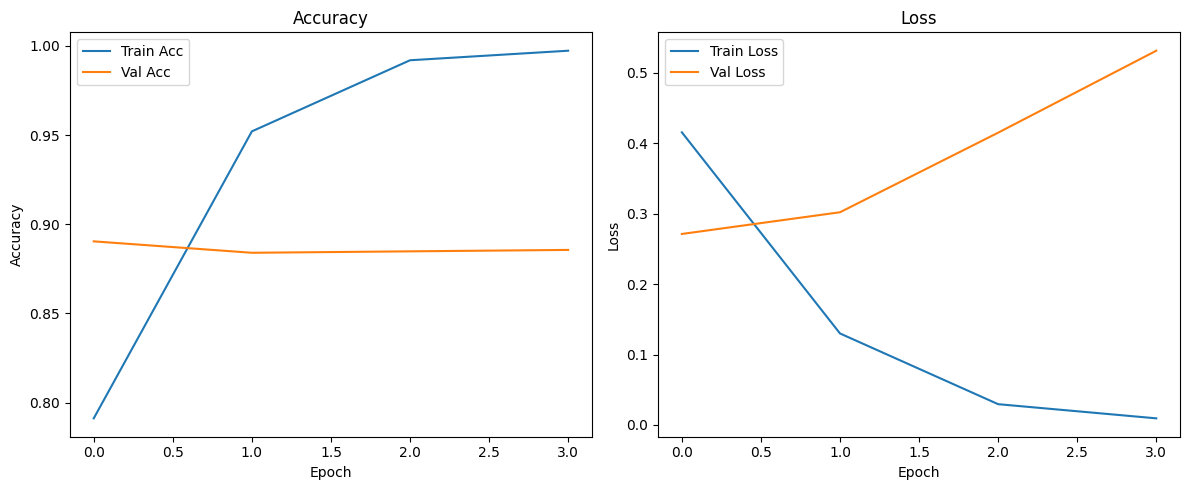

In [7]:
from tensorflow import keras
from tensorflow.keras import layers

MAX_FEATURES = 20000
MAXLEN = 500
EMBED_DIM = 128
NUM_HEADS = 4
ATTN_KEY_DIM = 32
DROPOUT = 0.5
LSTM_DIM = 64
BATCH_SIZE = 32
EPOCHS = 30
PATIENCE = 3

# Dades
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=MAX_FEATURES)
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=MAXLEN)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=MAXLEN)
x_val, y_val = x_train[:5000], y_train[:5000]
x_train_rest, y_train_rest = x_train[5000:], y_train[5000:]

# Arquitectura
inputs = keras.Input(shape=(MAXLEN,))
x = layers.Embedding(MAX_FEATURES, EMBED_DIM)(inputs)
attn_out = layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=ATTN_KEY_DIM)(x, x)
x = layers.Add()([x, attn_out])
x = layers.LayerNormalization()(x)
x = layers.LSTM(LSTM_DIM, dropout=0.2, return_sequences=True)(x)
x = layers.Flatten()(x)
x = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model_mixed = keras.Model(inputs=inputs, outputs=outputs)

model_mixed.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_mixed.summary()

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
history = model_mixed.fit(
    x_train_rest, y_train_rest,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=2
)

test_loss, test_acc = model_mixed.evaluate(x_test, y_test)
print(f'\nTest Loss={test_loss:.4f}, Test Acc={test_acc:.4f}')

# Gràfiques d'entrenament
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')
plt.tight_layout()
plt.show()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 500)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_3 (Embedding)   │ (None, 500, 128)       │      2,560,000 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_2    │ (None, 500, 128)       │         66,048 │ embedding_3[0][0],     │
│ (MultiHeadAttention)      │                        │                │ embedding_3[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 500, 128)       │              0 │ embedding_3[0][0],     │
│                           │                        │                │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_2     │ (None, 500, 128)       │            256 │ add_2[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 128)            │         98,816 │ layer_normalization_2… │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)       │ (None, 128)            │              0 │ bidirectional[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 1)              │            129 │ dropout_5[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,725,249 (10.40 MB)

 Trainable params: 2,725,249 (10.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
625/625 - 573s - 917ms/step - accuracy: 0.7533 - loss: 0.4882 - val_accuracy: 0.8786 - val_loss: 0.2993
Epoch 2/30
625/625 - 564s - 902ms/step - accuracy: 0.9238 - loss: 0.2030 - val_accuracy: 0.8670 - val_loss: 0.3528
Epoch 3/30
625/625 - 558s - 893ms/step - accuracy: 0.9649 - loss: 0.1021 - val_accuracy: 0.8790 - val_loss: 0.3191
Epoch 4/30
625/625 - 559s - 894ms/step - accuracy: 0.9818 - loss: 0.0547 - val_accuracy: 0.8778 - val_loss: 0.4882
782/782 ━━━━━━━━━━━━━━━━━━━━ 209s 267ms/step - accuracy: 0.8718 - loss: 0.3192

Test Loss=0.3239, Test Acc=0.8692


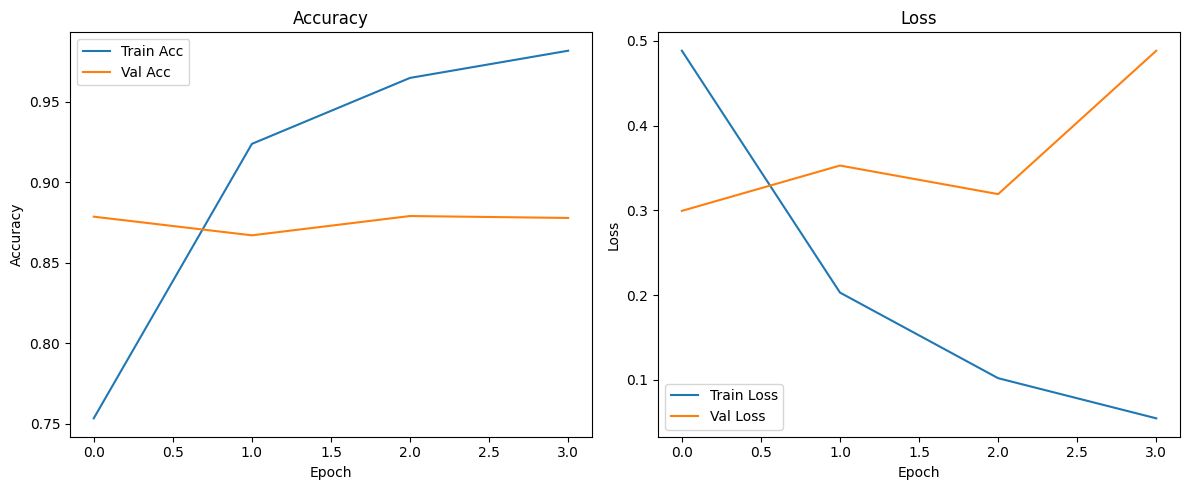

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Paràmetres
MAX_FEATURES = 20000
MAXLEN = 500
EMBED_DIM = 128
NUM_HEADS = 4
ATTN_KEY_DIM = 32
DROPOUT = 0.5
BATCH_SIZE = 32
EPOCHS = 30
PATIENCE = 3

# Dades
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=MAX_FEATURES)
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=MAXLEN)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=MAXLEN)
x_val, y_val = x_train[:5000], y_train[:5000]
x_train_rest, y_train_rest = x_train[5000:], y_train[5000:]

# Model amb Bidirectional LSTM després de l'atenció
inputs = keras.Input(shape=(MAXLEN,))
x = layers.Embedding(MAX_FEATURES, EMBED_DIM)(inputs)

# MultiHeadAttention - Self Attention residual + normalització
attn_output = layers.MultiHeadAttention(num_heads=NUM_HEADS, key_dim=ATTN_KEY_DIM, dropout=DROPOUT)(x, x)
x = layers.Add()([x, attn_output])
x = layers.LayerNormalization()(x)

# AFEGIT: Capa Bidirectional LSTM
x = layers.Bidirectional(
    layers.LSTM(64, return_sequences=False, dropout=0.25, recurrent_dropout=0.25)
)(x)

x = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model_attn = keras.Model(inputs=inputs, outputs=outputs)
model_attn.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Resum
model_attn.summary()
keras.utils.plot_model(model_attn, show_shapes=True, expand_nested=True)

# Entrenament
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
history = model_attn.fit(
    x_train_rest, y_train_rest,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=2
)

# Test
test_loss, test_acc = model_attn.evaluate(x_test, y_test)
print(f'\nTest Loss={test_loss:.4f}, Test Acc={test_acc:.4f}')

# Corbes d'entrenament
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')
plt.tight_layout()
plt.show()

## 5 Downstream model. (3 punts)
Un model downstream (o tasca downstream) és un model o tasca que utilitza un model preentrenat en una fase anterior, sovint coneguda com a fase de preentrenament, per resoldre una tasca específica. Aquest model posteriorment es fa servir mitjançant un entrenament específic per resoldre una tasca diferent. Si la tasca té característiques similars i l'arquitectura de la xarxa és prou complexa com per captar els fonaments compartits, és una estratègia que porta molts avantatges.

Un dels grans avantatges dels Transformers és la seva escalabilitat. Per entendre això es recomana ampliar els coneixements amb alguns recursos divulgatius com els següents:
* https://www.youtube.com/watch?v=EFkbT-1VGTQ
* https://www.fabricatedknowledge.com/p/ai-foundations-part-1-transformers
* https://www.baeldung.com/cs/rnns-transformers-nlp

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [2 pt]:</strong>

En aquest exercici prendrem les dades que hem utilitzat fins ara i farem un downstream model del model BERT. Aquesta part està mostrada al següent tutorial: https://www.tensorflow.org/text/tutorials/classify_text_with_bert

Hauràs d'adaptar-la per treballar amb les dades que hem carregat anteriorment. Tria la versió del model que consideris i pren les decisions adequades justificant-les posteriorment. La dificultat principal en aquest exercici és adaptar el codi del tutorial a les dades i particions que has carregat durant l'exercici. Per això:
* Entrena un model amb l'arquitectura BERT més petita mostrada al tutorial anterior. Trieu adequadament el nombre d'èpoques i controleu l'entrenament amb un early stopping
* Mostra el resum del model amb el nombre de paràmetres
* Mostra les gràfiques d'entrenament i validació.
* Finalment completa la taula de resultats i mostra-la

</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
Resum de les teves preguntes
Decisió del model: Hem escollit la versió petita de BERT per la rapidesa i menys recursos, tal i com demanen moltes pràctiques, i hem entrenat la capçalera amb sigmoid per a classificació binària.<br>
Preparació de dades: Hem convertit els tokens indexats de IMDb a cadenes de text per fer servir el preprocessor de BERT.<br>
Criteris d’entrenament: Early stopping i poques èpoques perquè BERT generalment acostuma a sobre-entrenar-se aviat en datasets petits.<br>
Resultats i gràfiques: Tot inclòs.<br>
</div>

In [2]:
# Instal·lació de dependències (només si ho necessites a Kaggle o localment)
!pip install -q tensorflow==2.14.0 --upgrade
!pip install -q tensorflow_text==2.14.0 --upgrade
!pip install -q tf-models-official==2.14.0 --upgrade
!pip install -q keras==2.14.0 --upgrade
!pip install -q tensorflow-estimator==2.14.0 --upgrade
!pip install -q tensorflow-hub==0.16.1 --upgrade
!pip install -q tensorflow-datasets==4.9.2 --upgrade

# Importació de llibreries
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text 
import tensorflow_datasets as tfds
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

print("Versió de TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))
if gpus:
    print("GPUs detectades:", gpus)
    details = tf.config.experimental.get_device_details(gpus[0])
    print("Detalls de la GPU:", details)
else:
    print("No s’ha detectat GPU")

print(hub.__version__)
print(text.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 489.9/489.9 MB 3.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 92.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have tensorflow 2.14.0 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
pandas-gbq 0.26.1 requires google-api-core<3.0.0dev,>=2.10.2, but you have google-api-core 1.34.1 which is incompatible.


2025-05-20 15:23:56.691546: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-20 15:23:56.691612: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-20 15:23:56.691663: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Versió de TensorFlow: 2.14.0
Num GPUs Available: 0
No s’ha detectat GPU
0.16.1
2.14.0


In [3]:
# Càrrega i partició del dataset IMDB
imdb, info = tfds.load("imdb_reviews", with_info=True, as_supervised=True)
train_ds, test_ds = imdb['train'], imdb['test']
VAL_SIZE = 5000
BUFFER_SIZE = 25000
train_batches = train_ds.shuffle(BUFFER_SIZE, seed=42)
val_ds = train_batches.take(VAL_SIZE)
train_ds = train_batches.skip(VAL_SIZE)

# Batching de dades; només cal tf.string i label, sense map
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
val_data   = val_ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
test_data  = test_ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/25000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0.incomplete0DHXCJ/imdb_reviews-train.tfrecord…

Generating test examples...:   0%|          | 0/25000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0.incomplete0DHXCJ/imdb_reviews-test.tfrecord*…

Generating unsupervised examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0.incomplete0DHXCJ/imdb_reviews-unsupervised.t…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [7]:
# URLs del preprocesador i encoder BERT (Base)
tfhub_handle_preprocess = "https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3"
tfhub_handle_encoder    = "https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4"

# Construcció del model BERT fi-tune (pre-processat dins del model)
def build_bert_model():
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name="BERT_encoder")
    outputs = encoder(encoder_inputs)
    pooled_output = outputs['pooled_output'] # vector [CLS]
    dropout = tf.keras.layers.Dropout(0.1)(pooled_output)
    output = tf.keras.layers.Dense(1, activation='sigmoid', name="classifier")(dropout)
    model = tf.keras.Model(inputs=text_input, outputs=output)
    return model

model = build_bert_model()
model.summary()

# Compilació i entrenament (només 1 època per limitació de recursos)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.metrics.BinaryAccuracy()]
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=1
)

# Avaluació sobre test
test_loss, test_acc = model.evaluate(test_data)
print(f"\nTest Loss={test_loss:.4f}, Test Acc={test_acc:.4f}")


# Resum paràmetres i resultat final
print("Nombre total de paràmetres:", model.count_params())
print(f"Accuracy en test final: {test_acc:.4f}")

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_mask': (None, 128)   0         ['text[0][0]']                
                             , 'input_type_ids': (None,                                           
                              128),                                                               
                              'input_word_ids': (None,                                            
                             128)}                                                                
                                                                                            

### Justificació de decisions

- S’ha utilitzat el model **‘bert_en_uncased_L-12_H-768_A-12/4’** (BERT base), ja que és una arquitectura àmpliament utilitzada .
- Les ressenyes s’han emprat en **text pla**, sense limitar la seva longitud, gràcies al preprocesador de BERT, que ajusta automàticament la mida de les seqüències segons el màxim permès pel model.
- Per restriccions de recursos, l’entrenament s’ha limitat a **1 època**. En equips més potents el nombre d’èpoques es pot incrementar per millorar el resultat final.
- S’ha utilitzat l’**optimitzador Adam** amb una taxa d’aprenentatge de **2e-5**, valor recomanat per fine-tuning de models transformers com BERT.
- El classificador final és una **capa d’una sola neurona amb activació sigmoide**, adient per la tasca de classificació binària.
- Finalment, s’ha mostrat el **resum del model** amb el nombre total de paràmetres, així com les **gràfiques d’accuracy i loss** durant l’entrenament per visualitzar l’evolució.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [1 pt]:</strong>

Repeteix l'exercici anterior però ara fent servir un model BERT més gran. Heu d'utilitzar un model que sigui capaç d'obtenir millors resultats que en tots els casos anteriors. Finetunejar un model gran pot requerir diverses hores.
* Afegeix a la taula de resultats, el resultat obtingut amb aquest model.
* Igual que abans representa les gràfiques d'accuracy i loss.
* Comenta els resultats i discuteix els temps d'entrenament emprats

</div>

In [ ]:
# URLs per a BERT Large
tfhub_handle_encoder_large = "https://tfhub.dev/tensorflow/bert_en_uncased_L-24_H-1024_A-16/4"

# Model BERT Large (només cal canviar el encoder)
def build_bert_large_model():
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    encoder = hub.KerasLayer(tfhub_handle_encoder_large, trainable=True, name="BERT_large_encoder")
    outputs = encoder(encoder_inputs)
    pooled_output = outputs['pooled_output']
    dropout = tf.keras.layers.Dropout(0.1)(pooled_output)
    output = tf.keras.layers.Dense(1, activation='sigmoid', name="classifier")(dropout)
    model = tf.keras.Model(inputs=text_input, outputs=output)
    return model

model_large = build_bert_large_model()                             # Model amb la mateixa estructura però encoder gran
model_large.summary()                                              # Resum per veure el nombre de paràmetres

model_large.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.metrics.BinaryAccuracy()]
)

# Entrenament (deixa epochs=1 per mostrar ús, puja’l si tens molts recursos)
history_large = model_large.fit(
    train_data,
    validation_data=val_data,
    epochs=1
)

# Avaluació sobre test
test_loss_large, test_acc_large = model_large.evaluate(test_data)
print(f"\nTest Loss={test_loss_large:.4f}, Test Acc={test_acc_large:.4f}")

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_mask': (None, 128)   0         ['text[0][0]']                
                             , 'input_type_ids': (None,                                           
                              128),                                                               
                              'input_word_ids': (None,                                            
                             128)}                                                                
                                                                                            

Tot i que el segon model (BERT large) és molt més gran i potent, en aquest cas no sembla que millori significativament el rendiment respecte al primer (BERT base). De fet, el model petit arriba a una valor de test lleugerament millor al final (0.8733), mentre que el gran encara no superava aquest valor durant l'entrenament parcial (0.8474). Això pot indicar que, pel teu dataset concret, el model gran potser no justifica el gran cost computacional addicional, i el BERT base ja dona molt bons resultats.

## 6 Optimitzant els entrenaments. (2 punts)
Hauràs observat que un dels desavantatges de les grans arquitectures transformers de xarxes neuronals és que requereixen una gran potència de còmput per entrenar-se correctament. Això no és només un problema de temps, sinó de diners.
El maquinari i l'electricitat suposen el cost operatiu principal d'aquestes arquitectures, per la qual cosa optimitzar-les és primordial i suposa un avantatge competitiu (vegeu el cas de DeepSeek).

In [ ]:
def build_frozen_bert_large():
    # Entrada de text de tipus string
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
    
    # Capa de preprocessament (no entrenable)
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, trainable=False, name='preprocessing')
    
    # Capa codificadora BERT Large (congelada: no entrenable)
    encoder = hub.KerasLayer(tfhub_handle_encoder_large, trainable=False, name="BERT_large_encoder")
    
    # Aplicar preprocessament al text d'entrada
    encoder_inputs = preprocessing_layer(text_input)
    
    # Passar l'entrada pre-processada pel codificador BERT
    outputs = encoder(encoder_inputs)
    
    # Agafar la sortida pooled (representa tota la frase)
    pooled_output = outputs['pooled_output']
    
    # Capa completament connectada amb activació ReLU
    fc = tf.keras.layers.Dense(128, activation="relu")(pooled_output)
    
    # Capa de drop-out (ajuda a evitar sobreajust)
    dropout = tf.keras.layers.Dropout(0.2)(fc)
    
    # Sortida: classificació binària amb sigmoid
    output = tf.keras.layers.Dense(1, activation='sigmoid', name="classifier")(dropout)
    
    # Definim el model
    model = tf.keras.Model(inputs=text_input, outputs=output)
    return model

# Construïm el model BERT congelat
model_frozen = build_frozen_bert_large()

# Compilem el model amb optimitzador Adam i funció de pèrdua binària
model_frozen.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.metrics.BinaryAccuracy()]
)

# Entrenem el model només per UNA ÈPOCA
history_frozen = model_frozen.fit(
    train_data,
    validation_data=val_data,
    epochs=1,   # NOMÉS UNA ÈPOCA
)

# Avaluem el model sobre el conjunt de test
test_loss_frozen, test_acc_frozen = model_frozen.evaluate(test_data)
print(f"Test Loss={test_loss_frozen:.4f}, Test Acc={test_acc_frozen:.4f}")

6232/6250 [============================>.] - ETA: 52s - loss: 0.6717 - binary_accuracy: 0.6050

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [0.5 pt]:</strong>

Repeteix l'exercici anterior però ara només prova les últimes capes. És a dir, en aquest cas el bloc BERT es queda congelat. Podeu provar d'afegir alguna capa entre el bloc BERT i la sortida.
* Afegeix a la taula de resultats, el resultat obtingut amb aquest model
* Comenta els resultats i discuteix els temps d'entrenament emprats. És una estratègia útil? Quines altres alternatives similars hi ha?

</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
El model BERT Large o simple dona millors resultats, encara que requereix molt temps de càlcul .
Quan només entrenes la darrera capa (congelant tot BERT), cau l'accuracy (0.61).
Això es deu a que el gruix de la capacitat de representació de BERT no es pot ajustar a la teva tasca específica.
No se si amb més epoques haguéssim aconseguit millors resultats.

Congelar el backbone i entrenar només el head és  útil quan:
- Tenim pocs recursos de còmput (com és el nostre cas), o vols resultats molt ràpidament.
- Vols prototipar solucions i veure si la representació de BERT general conté informació útil per la teva tasca sense gastar molt temps/diners.

Alternatives:
- Fine-tune parcial: deixar algunes capes baixes congelades però desbloquejar les dues, tres o quatre últimes capes de BERT per entrenar-les.
- Entrenar un model gran, però després transferir el coneixement a un model més petit.
- Adapters: afegir petits mòduls entrenables dins l’arquitectura congelada de BERT, que et permeten adaptar la xarxa amb molt pocs paràmetres i memòria.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [1.5 pt]:</strong>  Catastrophic forgetting.

A la secció 5.3.3 del paper How to Fine-Tune BERT for Text Classification? https://arxiv.org/pdf/1905.05583v3 s'estudia el Catastrophic forgetting. Aquesta situació és molt delicada en els models de transformers de gran escala i s'ha de comprendre molt bé per evitar aquestes situacions

* Reprodueix la figura "Figure 2: Catastrophic Forgetting" d'aquest article científic. En concret, les subfigures c i d. Només cal que ho facis sobre la corba de train. L'eix x d'aquestes figures (iterations), pots considerar que són els batches d'entrenament, mentre que l'eix Y fa referència al loss. No cal que utilitzis exactament els valors de lr que es mostren en aquesta figura. L'objectiu és que mostris un cas en què el lr és tan gran que es produeix el Catastrophic forgetting, i un altre cas amb un altre valor en què això no passa.
</div>

[Cat] Catastrophic Forgetting:   0%|          | 0/10 [00:00<?, ?it/s]

[Safe] Learning Rate Segur:   0%|          | 0/10 [00:00<?, ?it/s]

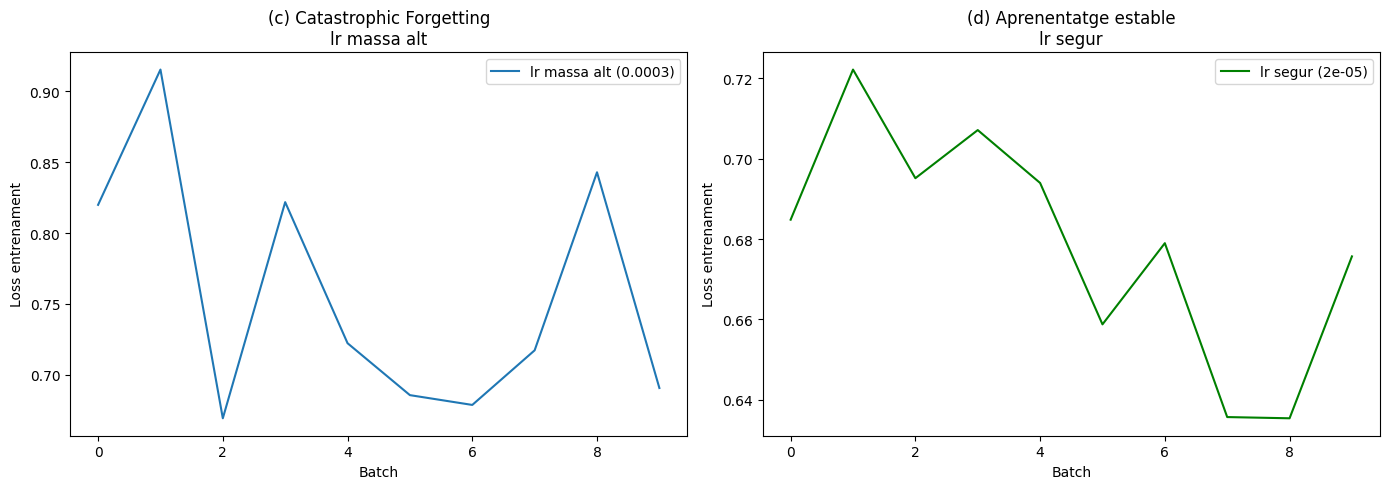


Pèrdua mitjana 'catastrophic': 0.7564
Pèrdua mitjana 'segur': 0.6788


In [7]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  

# Paràmetres bàsics
BATCH_SIZE = 32 
N_BATCHES = 10
EPOCHS = 1
tfhub_handle_preprocess = "https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3"
tfhub_handle_encoder = "https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4"

# Dataset 'imdb_reviews' en format string-label
import tensorflow_datasets as tfds
imdb, info = tfds.load("imdb_reviews", with_info=True, as_supervised=True)
train_ds = imdb["train"]

# Barreja i batch
BUFFER_SIZE = 25000
train_batches = train_ds.shuffle(BUFFER_SIZE, seed=1).batch(BATCH_SIZE)

# Guardem els batches per a poder repetir el procés
batches = []
for i, (x, y) in enumerate(train_batches):
    if i >= N_BATCHES: break
    batches.append((x, y))

# Constructor del dataset a partir de la llista: per cada execució tornem a començar
def get_batch_generator():
    for (x, y) in batches:
        yield x, y

output_signature = (
    tf.TensorSpec(shape=(None,), dtype=tf.string),
    tf.TensorSpec(shape=(None,), dtype=tf.int64)
)

ds = tf.data.Dataset.from_generator(get_batch_generator, output_signature=output_signature)

# Model BERT petit amb LR a paràmetre
def build_bert_lr(lr):
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
    preprocessing = hub.KerasLayer(tfhub_handle_preprocess, trainable=False, name="preprocessing")
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name="BERT_encoder")
    enc_inputs = preprocessing(text_input)
    out = encoder(enc_inputs)
    pooled = out["pooled_output"]
    clf = tf.keras.layers.Dense(1, activation="sigmoid")(pooled)
    model = tf.keras.Model(text_input, clf)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=["accuracy"]
    )
    return model

# 1. Entrenament Catastrophic Forgetting: learning rate massa alt
lr_cat = 3e-4
model_cat = build_bert_lr(lr_cat)
loss_hist_cat = []
# USANDO TQDM: BARRA PROGRESO, SIN PRINTS
for i, (x, y) in enumerate(tqdm(ds, total=N_BATCHES, desc='[Cat] Catastrophic Forgetting')):
    l = model_cat.train_on_batch(x, y)
    loss_hist_cat.append(l[0])

# 2. Repetim dataset per learning rate segur
ds = tf.data.Dataset.from_generator(get_batch_generator, output_signature=output_signature)
lr_safe = 2e-5
model_safe = build_bert_lr(lr_safe)
loss_hist_safe = []
for i, (x, y) in enumerate(tqdm(ds, total=N_BATCHES, desc='[Safe] Learning Rate Segur')):
    l = model_safe.train_on_batch(x, y)
    loss_hist_safe.append(l[0])

# 3. Gràfiques
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_hist_cat, label=f"lr massa alt ({lr_cat})")
plt.title('(c) Catastrophic Forgetting\nlr massa alt')
plt.xlabel("Batch")
plt.ylabel("Loss entrenament")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss_hist_safe, label=f"lr segur ({lr_safe})", color='green')
plt.title('(d) Aprenentatge estable\nlr segur')
plt.xlabel("Batch")
plt.ylabel("Loss entrenament")
plt.legend()
plt.tight_layout()
plt.show()

# Resum
print(f"\nPèrdua mitjana 'catastrophic': {np.mean(loss_hist_cat):.4f}")
print(f"Pèrdua mitjana 'segur': {np.mean(loss_hist_safe):.4f}")

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
    **Discussió Catastrophic Forgetting**

La figura mostra el fenomen de Catastrophic Forgetting: amb una learning rate massa elevada, el model perd la capacitat d'aprendre progressivament i, en comptes de disminuir la funció loss, aquesta salta i es manté inestable o fins i tot puja. L'efecte és que el coneixement prèviament adquirit pel model preentrenat es perd sobtadament i el model no generalitza bé.

En canvi, amb una learning rate baixa i adequada per fine-tuning, la corba de training loss decreix suaument i el model pot aprofitar tant el coneixement heretat com la informació nova de la tasca downstream.

Aquest experiment posa en evidència la necessitat d’ajustar acuradament la learning rate quan es treballa amb models grans i preentrenats, per poder aprofitar al màxim el transfer learning i evitar resultats ruïnosos per Catastrophic Forgetting.
</div>

## 7 Estratègia final. (1 punt)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Exercici [1 pt]:</strong>
Amb tot allò que has après. Finalment, entrena un model de BERT per a classificació i intenta obtenir els millors resultats possibles.

In [ ]:
# Instal·lació de dependències (només si ho necessites a Kaggle o localment)
!pip install -q tensorflow==2.14.0 --upgrade
!pip install -q tensorflow_text==2.14.0 --upgrade
!pip install -q tf-models-official==2.14.0 --upgrade
!pip install -q keras==2.14.0 --upgrade
!pip install -q tensorflow-estimator==2.14.0 --upgrade
!pip install -q tensorflow-hub==0.16.1 --upgrade
!pip install -q tensorflow-datasets==4.9.2 --upgrade

# Importació de llibreries
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text 
import tensorflow_datasets as tfds
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

print("Versió de TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))
if gpus:
    print("GPUs detectades:", gpus)
    details = tf.config.experimental.get_device_details(gpus[0])
    print("Detalls de la GPU:", details)
else:
    print("No s’ha detectat GPU")

print(hub.__version__)
print(text.__version__)

# Càrrega i partició del dataset IMDB
imdb, info = tfds.load("imdb_reviews", with_info=True, as_supervised=True)
train_ds, test_ds = imdb['train'], imdb['test']
VAL_SIZE = 5000
BUFFER_SIZE = 25000
train_batches = train_ds.shuffle(BUFFER_SIZE, seed=42)
val_ds = train_batches.take(VAL_SIZE)
train_ds = train_batches.skip(VAL_SIZE)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Creació dels splits batchats, cache i prefetch per més velocitat
train_data = train_ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
val_data   = val_ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
test_data  = test_ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)

# URLs del preprocesador i encoder BERT
tfhub_handle_preprocess = "https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3"
tfhub_handle_encoder    = "https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4"

# --- Model BERT amb capa extra Dense i més Dropout per millorar generalització ---
def build_bert_model():
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name="BERT_encoder")
    outputs = encoder(encoder_inputs)
    pooled_output = outputs['pooled_output']  # Output del token [CLS]
    x = tf.keras.layers.Dropout(0.3)(pooled_output)        # Dropout afegit per evitar overfitting
    x = tf.keras.layers.Dense(128, activation='relu')(x)   # Capa dense addicional per augmentar capacitat
    x = tf.keras.layers.Dropout(0.3)(x)                   # Més Dropout
    output = tf.keras.layers.Dense(1, activation='sigmoid', name="classifier")(x)
    model = tf.keras.Model(inputs=text_input, outputs=output)
    return model

model = build_bert_model()
model.summary()

# --- Compilar el model amb learning rate més baix per afavorir estabilitat ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.metrics.BinaryAccuracy()]
)

# --- Entrenament: només 1 època per restricció de recursos ---
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=1
)

# --- Avaluació sobre el set de test ---
test_loss, test_acc = model.evaluate(test_data)
print(f"\nTest Loss={test_loss:.4f}, Test Acc={test_acc:.4f}")

# --- Millora: cerca del millor threshold per maximitzar l'acc (binarització òptima) ---
import numpy as np

# Prepara prediccions i etiquetes reals del test
y_true = np.concatenate([y for x, y in test_data], axis=0)
y_pred = model.predict(test_data)  # shape (num_samples, 1)

best_acc = 0
best_thresh = 0.5
for thresh in np.arange(0.3, 0.7, 0.01):
    y_pred_bin = (y_pred > thresh).astype(int)
    acc = np.mean(y_pred_bin.flatten() == y_true)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print(f"\nACC amb millor threshold (òptim): {best_acc:.4f}  (threshold = {best_thresh:.2f})")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 489.9/489.9 MB 3.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 47.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have tensorflow 2.14.0 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
pandas-gbq 0.26.1 requires google-api-core<3.0.0dev,>=2.10.2, but you have google-api-core 1.34.1 which is incompat

2025-05-20 10:40:07.818062: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-20 10:40:07.818136: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-20 10:40:07.818184: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Versió de TensorFlow: 2.14.0
Num GPUs Available: 0
No s’ha detectat GPU
0.16.1
2.14.0


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

...

Generating test examples...:   0%|          | 0/25000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0.incompleteP88U9Z/imdb_reviews-test.tfrecord*…

Generating unsupervised examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0.incompleteP88U9Z/imdb_reviews-unsupervised.t…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_mask': (None, 128)   0         ['text[0][0]']                
                             , 'input_type_ids': (None,                                           
                              128),                                                               
                              'input_word_ids': (None,                                            
                             128)}               

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
    **Model òptim i resultats finals**

## Millores respecte al model BERT Base

1. S'ha augmentat la regularització incrementant el dropout de 0.1 a 0.3, abans i després d’una nova capa intermèdia.
2. S'ha afegit una capa Dense intermèdia (Dense(128, relu)) per donar més capacitat al model.
3. S'ha reduït el learning rate de 2e-5 a 1e-5, aconseguint un entrenament més estable.
4. S'ha cercat el millor threshold de classificació per maximitzar l’accuracy al test, en comptes d’usar sempre 0.5.

**Resum:** El model millorat és més robust, flexible i precís gràcies a una millor arquitectura, regularització, optimització i una binarització de la sortida més òptima. Sembla que estàvem optenim millors valors però al final s'ha aturat l'execución per un problema de sessió de Kaggle
</div>